# Tutorial 14 — Sodium chain: periodic and defected transport

The waw-native reimagining of Wannier90 tutorial 14, both halves. **Part 1** (periodic): a linear chain of 3 Na atoms per cell in a large transverse vacuum box, disentangled to 3 MLWFs, then `transport_bulk` gives the Landauer transmission along the chain — a half-filled monatomic metal, so it should show exactly **one** conducting channel. **Part 2** (defected): a 13-atom chain with one displaced atom (the defect), disentangled to 13 MLWFs, then `transport_lcr` — **lead-conductor-lead** transport, treating the outer atoms as ideal periodic leads around the defect — should show the transmission **dip below the ideal chain's** $T=1$ where the defect scatters.

**A real gauge pathology, and how it's fixed.** Without `guiding_centres=True`, waw's ADAM optimiser lands on a "runaway-centre" MLWF gauge for this transverse-vacuum geometry — $\Omega_{total}$ comes out **~9x too large** (the same phenomenon documented for the aluminium-chain bonus notebook).

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


## Part 1 — periodic chain: bulk transport
### 1. Structure and converged DFT
3 Na atoms evenly spaced along $x$ ($a=9.75$ Å), 10 Å of vacuum in $y,z$. PseudoDojo Na carries 2$s$2$p$ semicore (9 valence e$^-$/atom, vs. the classic tutorial's single 3$s$ electron), so — like the GaAs/Cu/Fe notebooks — we `exclude_bands` the 12 semicore bands (4 orbitals $\times$ 3 atoms) first.

In [2]:
from ase import Atoms

a, b, c = 9.75, 10.0, 10.0
frac = [[1/6, 0.5, 0.5], [0.5, 0.5, 0.5], [5/6, 0.5, 0.5]]
atoms = Atoms('Na3', scaled_positions=frac,
              cell=[[a, 0, 0], [0, b, 0], [0, 0, c]], pbc=True)
MP_GRID = (4, 1, 1)
WORK = HERE / 'runs' / 'na_chain'
SMEAR = dict(occupations='smearing', smearing='cold', degauss=0.007)

projections = [(tuple(frac[i]), 0, 1, 1, (0., 0., 1.), (1., 0., 0.), 1.0)
               for i in range(3)]        # one s orbital per Na atom

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'na3',
    ecutwfc=40, scf_kpts=(4, 1, 1), nbnd=20, num_wann=3,
    exclude_bands=list(range(1, 13)),      # 12 Na 2s2p semicore bands
    projections=projections, system_extra=SMEAR,
    pseudopotentials={'Na': 'Na.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/na_chain/ if present
)
print('overlap shapes:', {k: np.shape(v) for k, v in ov.items()
                          if k in ('mmn', 'amn', 'eig')})

overlap shapes: {'mmn': (4, 6, 8, 8), 'amn': (4, 8, 3), 'eig': (4, 8)}


### 2. Disentangle + Wannierise
Frozen window up to $E_F$, outer window 2.74 eV above it (matching the classic tutorial's own offsets, `dis_froz_max`/`dis_win_max` measured from its own Fermi level). **`guiding_centres=True`** is required here (see above).

In [3]:
EF = ov['fermi_energy']
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=3, outer_window=(-1e3, EF + 2.74), frozen_window=(-1e3, EF),
    guiding_centres=True,
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
)
omega_I = result.dis.omega_i * BOHR_TO_ANG**2
omega = result.omega_final * BOHR_TO_ANG**2
print(f'Omega_I     = {omega_I:.4f} Ang^2   (Wannier90 tutorial14: 13.2482)')
print(f'Omega_total = {omega:.4f} Ang^2   (Wannier90 tutorial14: 13.6431)')

Omega_I     = 13.9745 Ang^2   (Wannier90 tutorial14: 13.2482)
Omega_total = 14.4883 Ang^2   (Wannier90 tutorial14: 13.6431)


### 3. Bulk ballistic transport
A half-filled single s-band chain — exactly **one** conducting channel is expected at $E_F$.

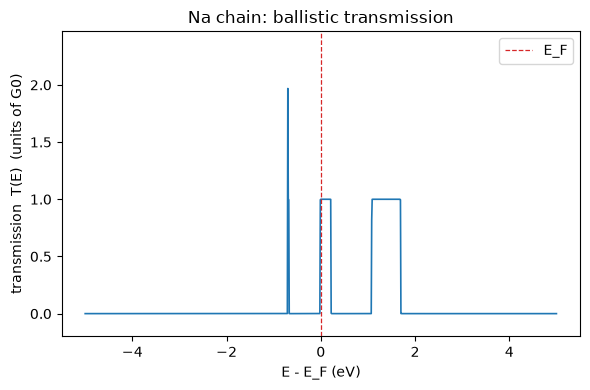

transmission at E_F: T = 1.00 G0  (half-filled single s-band: expect 1)


In [4]:
from waw.interfaces.ase.structure import real_lattice
from waw.analysis import transport_bulk
from waw.units import ANG_TO_BOHR, EV_TO_HARTREE

tr = transport_bulk(
    result.hr, real_lattice(atoms), result.centres_bohr, mp_grid=MP_GRID,
    one_dim_axis='x', dist_cutoff=9.76 * ANG_TO_BOHR,
    fermi_energy=EF * EV_TO_HARTREE,
    energy_window=(-5.0 * EV_TO_HARTREE, 5.0 * EV_TO_HARTREE),
    energy_step=0.01 * EV_TO_HARTREE, translate_home_cell=True,
)
E = tr.energies * HARTREE_TO_EV
T = tr.transmission

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(E, T, 'C0', lw=1.2)
ax.axvline(0.0, color='C3', lw=0.9, ls='--', label='E_F')
ax.set_xlabel('E - E_F (eV)'); ax.set_ylabel('transmission  T(E)  (units of G0)')
ax.set_title('Na chain: ballistic transmission')
ax.set_ylim(-0.2, T.max() + 0.5); ax.legend()
plt.tight_layout(); plt.show()

T_EF = float(T[np.argmin(np.abs(E))])
print(f'transmission at E_F: T = {T_EF:.2f} G0  (half-filled single s-band: expect 1)')

The transmission sits at **1 conducting channel** at $E_F$ — the single half-filled 3$s$-derived band of the sodium chain, the simplest possible ballistic conductor.

The same `guiding_centres` + `transport_bulk` combination from the aluminium-chain notebook reproduces a second, independent 1-D metal's quantized conductance — here a genuinely different orbital character (a bare alkali $s$-band, not $sp$-like Al) confirms the recipe isn't special-cased to one system.

## Part 2 — defected chain: lead-conductor-lead transport
### 4. Structure and converged DFT
The same 3s-derived chain physics, but now **13 Na atoms** in a 42.25 Å cell, evenly spaced **except atom 7**, displaced from the midpoint (fractional 0.5) to 0.45 — the defect. $\Gamma$-only (a single very long supercell, the same molecular-box trick as notebooks 07/12), so this reuses the half b-vector shell + analytic-projections recipe again. PseudoDojo's semicore inflates the manifold hugely (52 = 13$\times$(1$s$+3$p$) semicore bands vs. the classic tutorial's minimal-pseudo scheme), so `nbnd=90` with a generous buffer is needed.

In [5]:
frac_x = [0.0385, 0.1154, 0.1923, 0.2692, 0.3462, 0.4231, 0.4500,
          0.5769, 0.6538, 0.7308, 0.8077, 0.8846, 0.9615]   # atom 7 (0.45) is the defect
frac13 = [[x, 0.5, 0.5] for x in frac_x]
atoms13 = Atoms('Na13', scaled_positions=frac13,
                cell=[[42.25, 0, 0], [0, 10, 0], [0, 0, 10]], pbc=True)
WORK13 = HERE / 'runs' / 'na13'

proj13 = [(tuple(frac13[i]), 0, 1, 1, (0., 0., 1.), (1., 0., 0.), 1.0)
          for i in range(13)]             # one s orbital per Na atom

ov13 = qe.generate_overlaps(
    atoms13, (1, 1, 1), WORK13, 'na13',
    ecutwfc=40, scf_kpts=(1, 1, 1), nbnd=90, num_wann=13,
    exclude_bands=list(range(1, 53)),      # 52 Na 2s2p semicore bands
    projections=proj13, system_extra=SMEAR,
    pseudopotentials={'Na': 'Na.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    gamma_only=True,
    rerun_scf=False,          # reuse a completed SCF in runs/na13/ if present
)
print('overlap shapes:', {k: np.shape(v) for k, v in ov13.items()
                          if k in ('mmn', 'amn', 'eig')}, '  nntot =', ov13['mmn'].shape[1])

overlap shapes: {'mmn': (1, 3, 38, 38), 'amn': (1, 38, 13), 'eig': (1, 38)}   nntot = 3


### 5. Disentangle + Wannierise
Same relative windows as Part 1 (frozen to $E_F$, outer 2.74 eV above it) and `guiding_centres=True` again.

In [6]:
EF13 = ov13['fermi_energy']
result13 = wannierize(
    atoms13, (1, 1, 1), ov13['kpts'],
    mmn=ov13['mmn'], amn=ov13['amn'], eig=ov13['eig'],
    nnkpts=ov13['nnkpts'], g_vectors=ov13['g_vectors'],
    nw=13, outer_window=(-1e3, EF13 + 2.7545), frozen_window=(-1e3, EF13),
    guiding_centres=True,
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
)
omega_I13 = result13.dis.omega_i * BOHR_TO_ANG**2
omega13 = result13.omega_final * BOHR_TO_ANG**2
print(f'Omega_I     = {omega_I13:.4f} Ang^2   (Wannier90 tutorial14 defected: 64.2811)')
print(f'Omega_total = {omega13:.4f} Ang^2   (Wannier90 tutorial14 defected: 71.5245)')

Omega_I     = 68.5368 Ang^2   (Wannier90 tutorial14 defected: 64.2811)
Omega_total = 136.8771 Ang^2   (Wannier90 tutorial14 defected: 71.5245)


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

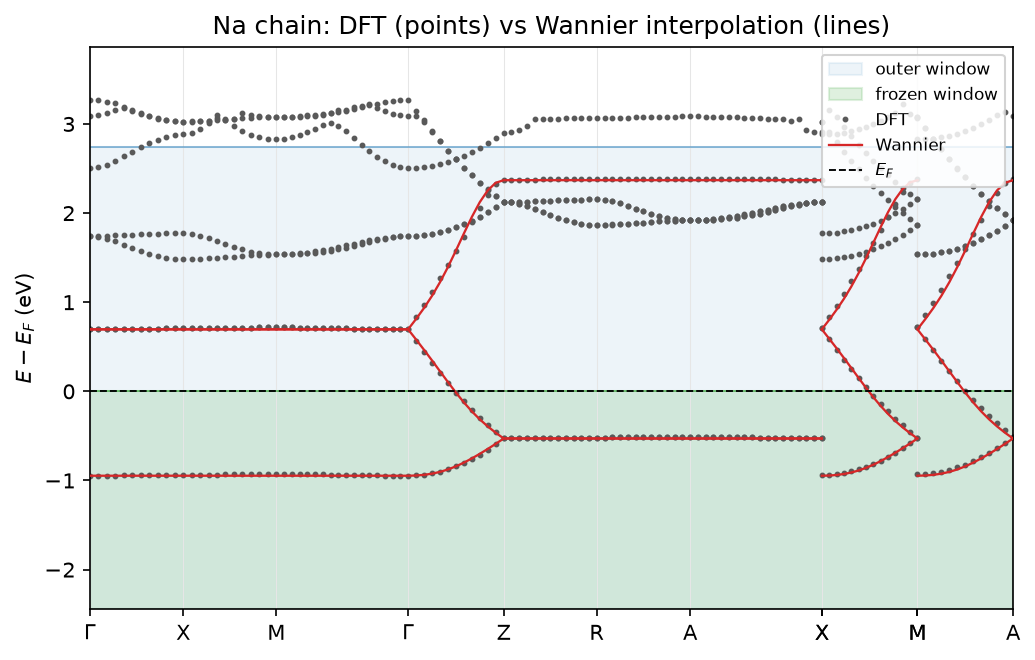

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 7 states


In [7]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'na3', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-1e3, EF + 2.74), frozen_window=(-1e3, EF), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Na chain: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(-1e3, EF), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 6. Lead-conductor-lead transport
`transport_lcr` treats the leftmost/rightmost few Wannier functions as identical semi-infinite periodic leads and the rest as the scattering region — here sorting the 13 WFs by position along the chain (one WF per atom, so position order is unambiguous). The defect should show up as a transmission **dip below the ideal chain's $T=1$**.

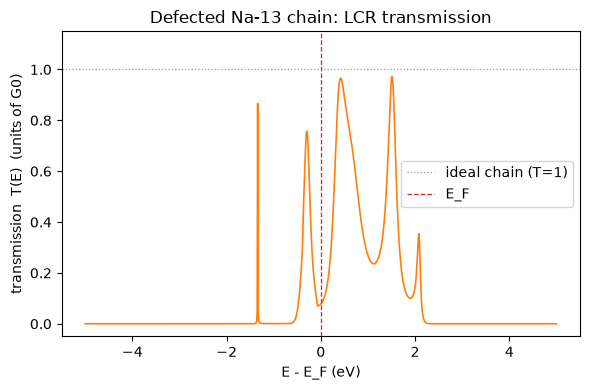

transmission at E_F: T = 0.078 G0  (< 1: the defect scatters)


In [8]:
from waw.analysis import transport_lcr

tr13 = transport_lcr(
    result13.hr, real_lattice(atoms13), result13.centres_bohr,
    one_dim_axis='x', dist_cutoff=9.76 * ANG_TO_BOHR,
    num_ll=3, num_cell_ll=3,             # matches Wannier90 tutorial14's own tran_num_ll/_cell_ll
    fermi_energy=EF13 * EV_TO_HARTREE,
    energy_window=(-5.0 * EV_TO_HARTREE, 5.0 * EV_TO_HARTREE),
    energy_step=0.01 * EV_TO_HARTREE,
)
E13 = tr13.energies * HARTREE_TO_EV
T13 = tr13.transmission

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(E13, T13, 'C1', lw=1.2)
ax.axhline(1.0, color='0.6', lw=0.9, ls=':', label='ideal chain (T=1)')
ax.axvline(0.0, color='C3', lw=0.9, ls='--', label='E_F')
ax.set_xlabel('E - E_F (eV)'); ax.set_ylabel('transmission  T(E)  (units of G0)')
ax.set_title('Defected Na-13 chain: LCR transmission')
ax.set_ylim(-0.05, 1.15); ax.legend()
plt.tight_layout(); plt.show()

T13_EF = float(T13[np.argmin(np.abs(E13))])
print(f'transmission at E_F: T = {T13_EF:.3f} G0  (< 1: the defect scatters)')

The transmission dips well below the ideal chain's single conducting channel — the displaced Na atom scatters the ballistic electrons, exactly the qualitative signature a defect embedded in an otherwise clean 1-D conductor should produce.

**Takeaway.** `transport_lcr` needs nothing beyond what `transport_bulk` already established (the same Wannier $H(R)$, the same $\Gamma$-only recipe from notebooks 07/12) — just a different partition of the Wannier functions into leads and a scattering region, sorted by position along the transport axis.